## __SIMULASI PADA LITHIUM HYDRIDE__ ##

__Alur dan tujuan__ nya sama seperti simulasi pada hydrogen, untuk mengetahui bagaiaman energi terenda berubah ketika jarak antar atom nya diubah.

    Molekul LiH memiliki lebih banyak elektron dibanding H2, sehingga Hamiltoniannya akan lebih kompleks dan julah qubit yg dibutuhkan lebih banyak

### __1. IMPORT LIBRARIES__ ##

In [5]:
import numpy as np
from scipy.sparse import linalg

import cirq
import openfermion as of
import openfermionpyscf as ofpyscf
import matplotlib.pyplot as plt

### __2. INISIALISASI__ ###

In [6]:
# Create a list of 17 bond lengths for the Hydrogen molecule
bond_lengths = np.array([1.0, 1.2, 1.3, 1.39, 1.4, 1.4011, 1.41, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2])/2

# Create an empty array to store the ground state energies
# simulated at different bond lengths
energy = []

### __3. SIMULATE THE GROUND STATE ENERGY OF THE HYDROGEN MOLECULE AT EACH BOND LENGTH__ ###

In [7]:
for bond_length in bond_lengths:

	# Set molecule parameters
	geometry = [('Li', (0.0, 0.0, 0.0)), ('H', (0.0, 0.0, bond_length))]
	basis = 'sto-3g'
	multiplicity = 1
	charge = 0

	# Perform electronic structure calculations and
	# obtain Hamiltonian as an InteractionOperator
	hamiltonian = ofpyscf.generate_molecular_hamiltonian(
	    geometry, basis, multiplicity, charge)

	# Convert to a FermionOperator
	hamiltonian_ferm_op = of.get_fermion_operator(hamiltonian)

	# Map to QubitOperator using the JWT
	hamiltonian_bk = of.bravyi_kitaev(hamiltonian_ferm_op)

	# Convert to Scipy sparse matrix
	hamiltonian_bk_sparse = of.get_sparse_operator(hamiltonian_bk)

	# Compute ground energy
	eigs, _ = linalg.eigsh(hamiltonian_bk_sparse, k=1, which='SA')
	ground_energy = eigs[0]

	# Store the ground state energy at each bond length in the energy array
	if bond_length == bond_lengths[0]:
		energy = np.array(ground_energy)
	else:
		energy = np.append(energy, ground_energy)

### __4. PLOT__ ###

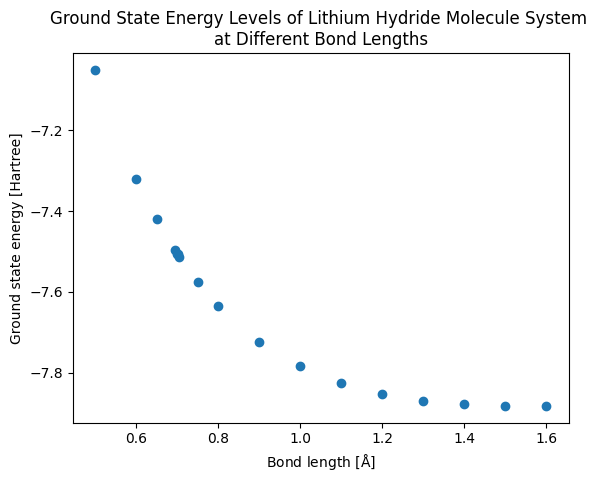

In [8]:
# Plot the energy curve from this study
plt.scatter(bond_lengths, energy, marker = "o", label = "This Study")

# Add labels, title and legend on the plot
plt.xlabel('Bond length [$\mathrm{\AA}$]')
plt.ylabel('Ground state energy [Hartree]')
plt.title('Ground State Energy Levels of Lithium Hydride Molecule System \nat Different Bond Lengths')
plt.show()